In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

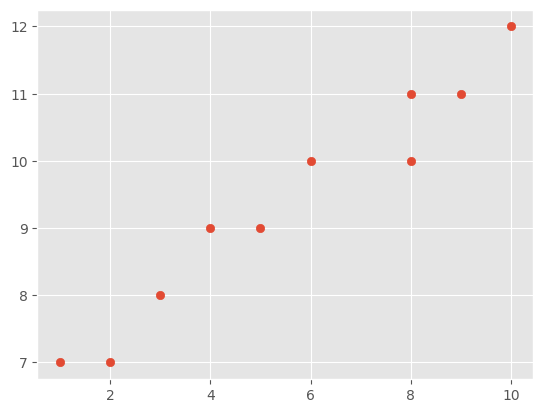

In [2]:
x=np.array([1,2,3,4,5,6,8,8,9,10],dtype=np.float64)
y=np.array([7,7,8,9,9,10,10,11,11,12],dtype=np.float64)
plt.scatter(x,y)
plt.show()

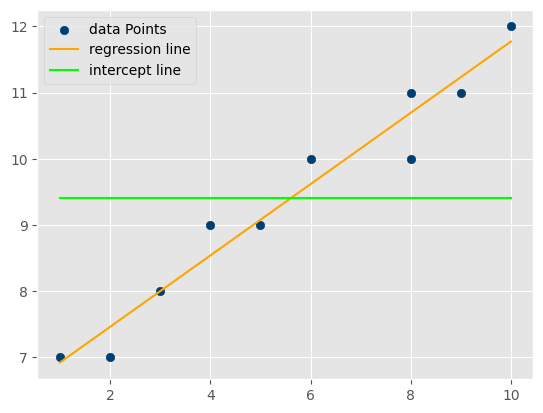

In [3]:
#calculate slope 
def calc_slope(x_values, y_values):
    rho = np.corrcoef(x_values, y_values)[0][1]
    std_y = y_values.std()
    std_x = x_values.std()
    m = rho * (std_y / std_x)
    return m


def intercept(x_values, y_values, slope):
    mean_x = x_values.mean()
    mean_y = y_values.mean()
    c = mean_y - m * mean_x
    return c

fig, ax = plt.subplots()
ax.scatter(x, y,color='#003F72',label='data Points')
m = calc_slope(x, y)
c = intercept(x, y, m)

regression_line = m*x + c
ax.plot(x, regression_line, color='#FFA500', label='regression line')

intercept_line = np.array([y.mean() for _ in x])
ax.plot(x, intercept_line,label='intercept line', color='#00FF00')
ax.legend()
plt.show()

In [4]:
calc_slope(x, y)

np.float64(0.5393518518518519)

# MODEL EVALUATION

In [5]:
ess = ((regression_line - intercept_line) ** 2).sum()
ess

np.float64(25.133796296296296)

In [7]:
model_df =  1
mse_model = ess / model_df
mse_model

np.float64(25.133796296296296)

In [11]:
rss = ((regression_line-y) ** 2).sum()
rss

np.float64(1.266203703703704)

In [13]:
residual_df = len(y) - 2
residual_df

8

In [14]:
mse_residual = rss / residual_df
mse_residual

np.float64(0.158275462962963)

In [15]:
f_statistic = mse_model / mse_residual
f_statistic

np.float64(158.7978062157221)

In [16]:
from scipy import stats
p_value = stats.f.sf(f_statistic, model_df, residual_df)
p_value

np.float64(1.4755820678821617e-06)

## goodness of Fit
- r**2

In [17]:
tss = ((y - y.mean()) ** 2).sum()
tss

np.float64(26.4)

In [18]:
r_squared = ess / tss
r_squared

np.float64(0.9520377384960719)